# Wine Quality Multiple Linear Regression

本 Notebook 依照 CRISP-DM 完成 Kaggle Wine Quality Dataset 的多元線性回歸分析。資料來源：`https://www.kaggle.com/datasets/yasserh/wine-quality-dataset`。

分析包含單變數線性回歸、全部 11 個特徵的多元線性回歸、SelectKBest 前 5 特徵模型、MAE/MSE/RMSE/R² 評估，以及 95% 預測區間。

In [1]:
!pip -q install kagglehub pandas numpy matplotlib seaborn scikit-learn statsmodels joblib

from pathlib import Path
import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
OUTPUT_DIR = Path('wine_quality_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

c:\Users\note\Desktop\L3作業\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Understanding and Preparation

使用 KaggleHub 自動下載資料。`Id` 是識別欄位，因此移除；`quality` 是目標欄位，其餘 11 欄是輸入特徵。

In [2]:
dataset_dir = Path(kagglehub.dataset_download('yasserh/wine-quality-dataset'))
csv_candidates = list(dataset_dir.rglob('WineQT.csv')) or list(dataset_dir.rglob('*.csv'))
data_path = csv_candidates[0]
df = pd.read_csv(data_path)
df.columns = df.columns.str.strip().str.replace(' ', '_', regex=False)
df = df.drop(columns=['Id', 'id'], errors='ignore')
X = df.drop(columns=['quality'])
y = df['quality']
print('資料路徑：', data_path)
print('資料維度：', df.shape)
display(df.head())
display(df.describe())
print('缺失值：')
display(df.isna().sum())
assert X.shape[1] == 11

資料路徑： C:\Users\note\.cache\kagglehub\datasets\yasserh\wine-quality-dataset\versions\1\WineQT.csv
資料維度： (1143, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


缺失值：


fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

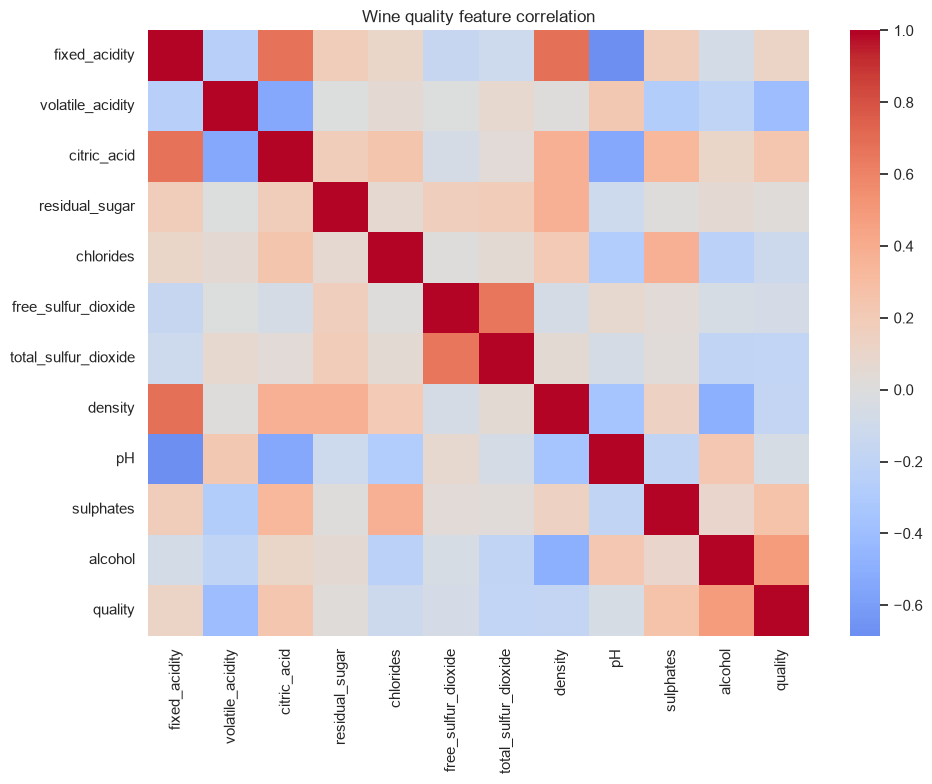

In [3]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Wine quality feature correlation')
plt.tight_layout()
plt.show()

## Modeling and Feature Selection

資料以 80/20 切分，並固定 `random_state=42`。SelectKBest 只在訓練資料中選取前 5 個特徵，以避免資料洩漏。

,Model,Features,N_features,MAE,MSE,RMSE,R2
1,B_Multiple_all11,"fixed_acidity, volatile_acidity, citric_acid, ...",11,0.477340,0.380032,0.616468,0.317069
2,C_Selected_top5,"volatile_acidity, citric_acid, density, sulpha...",5,0.483385,0.385590,0.620959,0.307082
0,A_Simple_alcohol,alcohol,1,0.526542,0.417547,0.646179,0.249654


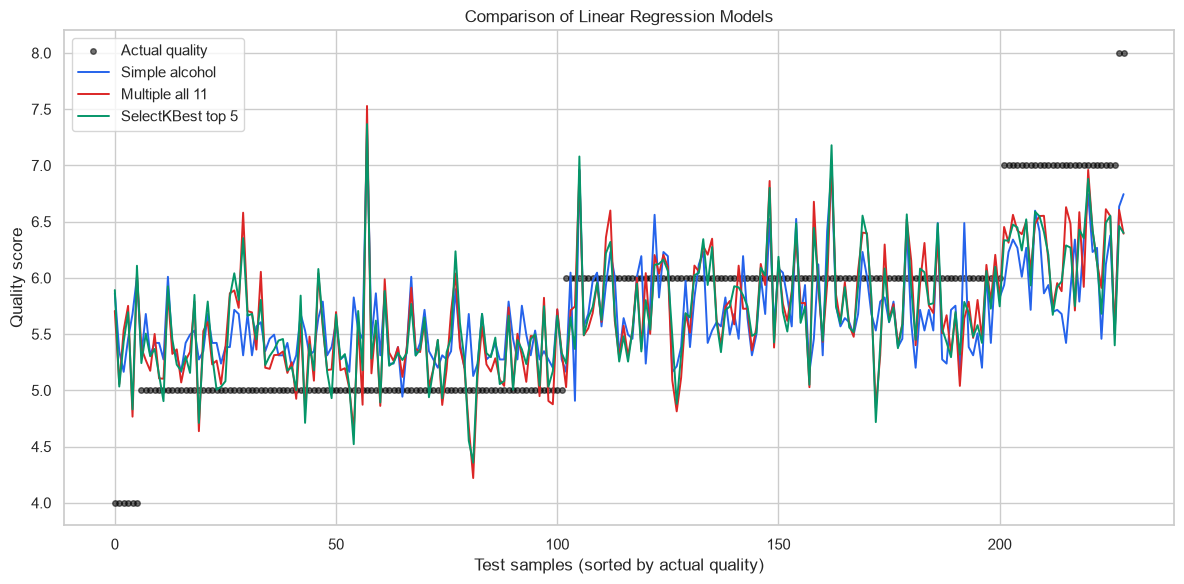

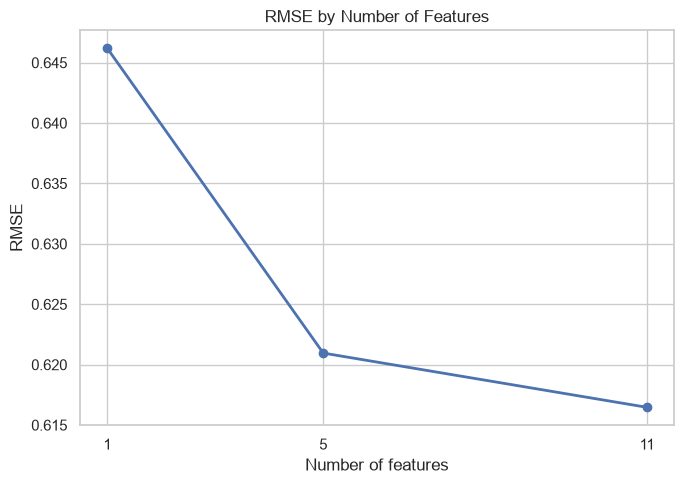

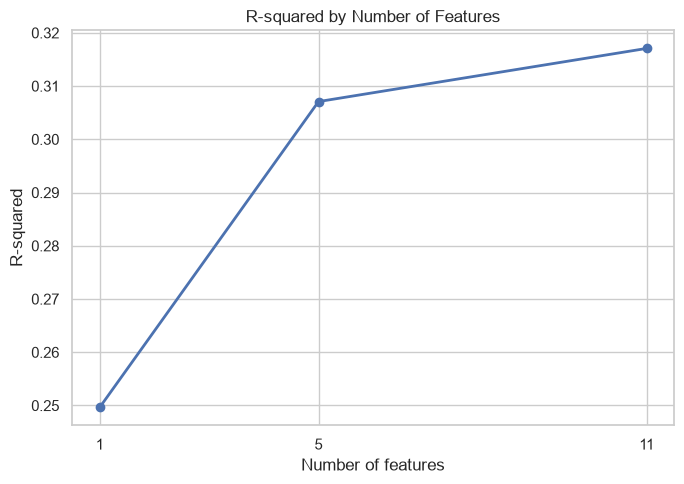

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

def make_pipeline(selected=False):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if selected:
        steps.append(('select', SelectKBest(score_func=f_regression, k=5)))
    steps.append(('reg', LinearRegression()))
    return Pipeline(steps)

models = {
    'A_Simple_alcohol': (['alcohol'], make_pipeline()),
    'B_Multiple_all11': (list(X.columns), make_pipeline()),
    'C_Selected_top5': (list(X.columns), make_pipeline(selected=True)),
}

results = []
predictions = {}
for name, (columns, model) in models.items():
    model.fit(X_train[columns], y_train)
    prediction = model.predict(X_test[columns])
    predictions[name] = prediction
    mse = mean_squared_error(y_test, prediction)
    selected_cols = columns
    if name == 'C_Selected_top5':
        selected_cols = X_train[columns].columns[model.named_steps['select'].get_support()].tolist()
    results.append({
        'Model': name,
        'Features': ', '.join(selected_cols),
        'N_features': len(selected_cols),
        'MAE': mean_absolute_error(y_test, prediction),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_test, prediction),
    })
metrics = pd.DataFrame(results).sort_values('RMSE')
display(metrics)
metrics.to_csv(OUTPUT_DIR / '02_model_metrics.csv', index=False, encoding='utf-8-sig')

comparison_order = np.argsort(y_test.to_numpy())
plt.figure(figsize=(12, 6))
plt.scatter(np.arange(len(y_test)), y_test.to_numpy()[comparison_order], color='black', s=16, alpha=0.55, label='Actual quality')
colors = {'A_Simple_alcohol': '#2563eb', 'B_Multiple_all11': '#dc2626', 'C_Selected_top5': '#059669'}
labels = {'A_Simple_alcohol': 'Simple alcohol', 'B_Multiple_all11': 'Multiple all 11', 'C_Selected_top5': 'SelectKBest top 5'}
for name, prediction in predictions.items():
    plt.plot(np.arange(len(y_test)), prediction[comparison_order], linewidth=1.4, color=colors[name], label=labels[name])
plt.xlabel('Test samples (sorted by actual quality)')
plt.ylabel('Quality score')
plt.title('Comparison of Linear Regression Models')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_model_comparison.png', dpi=200)
plt.show()

chart_metrics = metrics.sort_values('N_features')
plt.figure(figsize=(7, 5))
plt.plot(chart_metrics['N_features'], chart_metrics['RMSE'], marker='o', linewidth=2)
plt.xticks(chart_metrics['N_features'])
plt.xlabel('Number of features')
plt.ylabel('RMSE')
plt.title('RMSE by Number of Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_rmse_by_features.png', dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(chart_metrics['N_features'], chart_metrics['R2'], marker='o', linewidth=2)
plt.xticks(chart_metrics['N_features'])
plt.xlabel('Number of features')
plt.ylabel('R-squared')
plt.title('R-squared by Number of Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_r2_by_features.png', dpi=200)
plt.show()

## Evaluation: Prediction Interval

使用模型 C 的 OLS 統計結果建立單筆 95% prediction interval。預測區間同時考慮平均估計的不確定性與單筆新觀測的誤差。

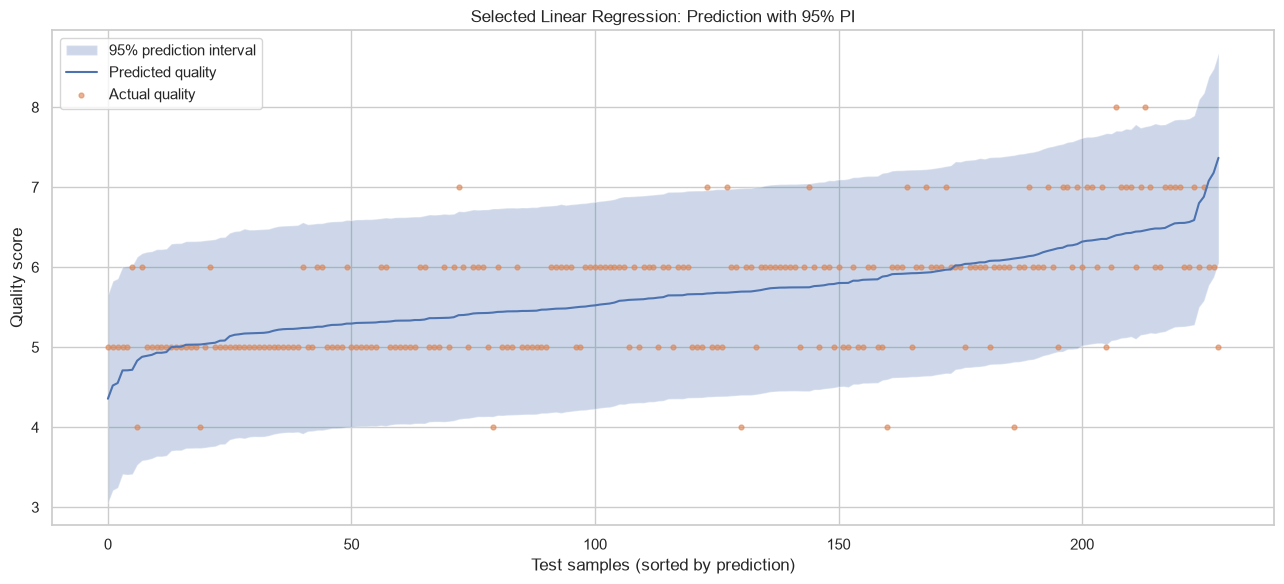

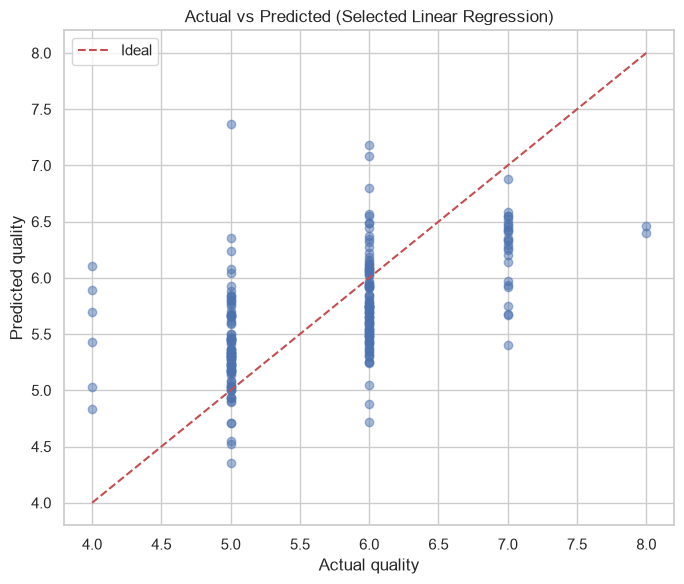

SelectKBest features: ['volatile_acidity', 'citric_acid', 'density', 'sulphates', 'alcohol']
95% PI coverage: 0.952
Mean PI width: 2.5916


In [5]:
selected_pipe = models['C_Selected_top5'][1]
selector = selected_pipe.named_steps['select']
selected_names = X_train.columns[selector.get_support()].tolist()
imputer = selected_pipe.named_steps['imputer']
tr_selected = selector.transform(imputer.transform(X_train))
te_selected = selector.transform(imputer.transform(X_test))
ols = sm.OLS(y_train.to_numpy(), sm.add_constant(tr_selected, has_constant='add')).fit()
frame = ols.get_prediction(sm.add_constant(te_selected, has_constant='add')).summary_frame(alpha=0.05)
order = np.argsort(frame['mean'].to_numpy())
actual = y_test.to_numpy()[order]
predicted = frame['mean'].to_numpy()[order]
lower = frame['obs_ci_lower'].to_numpy()[order]
upper = frame['obs_ci_upper'].to_numpy()[order]
x_axis = np.arange(len(order))

plt.figure(figsize=(13, 6))
plt.fill_between(x_axis, lower, upper, alpha=0.28, label='95% prediction interval')
plt.plot(x_axis, predicted, label='Predicted quality')
plt.scatter(x_axis, actual, s=12, alpha=0.6, label='Actual quality')
plt.xlabel('Test samples (sorted by prediction)')
plt.ylabel('Quality score')
plt.title('Selected Linear Regression: Prediction with 95% PI')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_prediction_interval.png', dpi=200)
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_test, frame['mean'], alpha=0.5)
limits = [min(y_test.min(), frame['mean'].min()), max(y_test.max(), frame['mean'].max())]
plt.plot(limits, limits, 'r--', label='Ideal')
plt.xlabel('Actual quality')
plt.ylabel('Predicted quality')
plt.title('Actual vs Predicted (Selected Linear Regression)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_actual_vs_predicted.png', dpi=200)
plt.show()

coverage = np.mean((y_test.to_numpy() >= frame['obs_ci_lower'].to_numpy()) & (y_test.to_numpy() <= frame['obs_ci_upper'].to_numpy()))
print('SelectKBest features:', selected_names)
print('95% PI coverage:', round(coverage, 4))
print('Mean PI width:', round(float(np.mean(upper - lower)), 4))

## Conclusion

本次資料共有 1,143 筆、11 個輸入特徵。全部特徵模型 RMSE 為 0.6165、R² 為 0.3171；SelectKBest 前 5 特徵模型 RMSE 為 0.6210、R² 為 0.3071。前 5 個特徵為 `volatile_acidity`、`citric_acid`、`density`、`sulphates`、`alcohol`。模型 C 的 95% 預測區間涵蓋率為 0.9520。線性回歸具有可解釋性，但品質分數離散且分布集中，因此適合作為透明基準模型。